# Winds of Empire — 100 Years at Sea
## Explainer Notebook

**Course:** DTU 02806 Social Data Analysis & Visualization — Spring 2026
**Dataset:** CLIWOC 2.1 (Climatological Database for the World's Oceans, 1662–1850)

---


## 1. Motivation

### What is the CLIWOC dataset?

The **CLIWOC dataset** (Climatological Database for the World's Oceans) is a large-scale digitisation project that transcribed daily ship logbooks from the Dutch, British, Spanish, and French maritime archives. Covering 1662–1850, it contains over 287,000 daily observations recording position, wind direction, wind force, weather conditions, and occasionally encounters with other vessels.

The dataset was assembled primarily for climate science — pre-industrial weather observations are rare, and ship logbooks are one of the few systematic records that exist. But the same data also encode the social and political history of European maritime expansion.

### Why is it compelling for Social Data Analysis?

- **Historical scope:** 100 years spanning the Seven Years' War, the American and French Revolutions, and the Napoleonic Wars.
- **Multi-national:** Four nations recorded the same oceans in four languages, offering natural cross-cultural comparisons.
- **Multi-dimensional:** The dataset contains weather, position, voyage routes, encounter records, and ship metadata — enabling linked analysis across geography, time, language, and network.
- **Quantitative + qualitative:** Wind descriptions range from precise numeric Beaufort codes to rich free-text observations, enabling both statistical and linguistic analysis.

### What is the end-user experience goal?

A non-technical reader should be able to open the website and come away understanding:
1. **Time:** How the relative power of four European nations at sea shifted dramatically over 100 years.
2. **Space:** The actual ocean routes they sailed, visualised on an interactive globe.
3. **Language:** How each nation described the sea in its own terms and how standardisation began with Beaufort's scale.
4. **Network:** Who met whom at sea, and what that network reveals about alliances, rivalries, and trade.


## 2. Basic Stats & Data Cleaning

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/cliwoc_clean.csv', low_memory=False)
print("Shape:", df.shape)
print("\nNations:", df['Nationality'].value_counts().to_dict())
print("\nYear range:", df['year_int'].min(), "–", df['year_int'].max())
df.head(3)


Shape: (251456, 187)

Nations: {'Dutch': 104530, 'British': 92498, 'Spanish': 45908, 'French': 8520}

Year range: 1750 – 1850


,YR,MO,DY,HR,LAT,LON,Lat,Lon,IM,ATTC,...,SeaIce,TrivialCorrection,Release,year_int,month_int,day_int,date,beaufort_era,wind_description,unique_voyage_id
0,1827,8,16,500.0,-692.0,10310.0,-6.92,103.10,0,1,...,0.0,0.0,CLIWOC VERSION 1.0,1827,8,16,1827-08-16 00:00:00,Beaufort,UNKNOWN ZO GOED WEER,ABEL TASMAN_18270816
1,1827,8,17,500.0,-827.0,10047.0,-8.27,100.47,0,1,...,0.0,0.0,CLIWOC VERSION 1.0,1827,8,17,1827-08-17 00:00:00,Beaufort,UNKNOWN ZO BRAMZEILSKOELTE EN MINDERE KOELTE G...,ABEL TASMAN_18270816
2,1827,8,18,500.0,-943.0,9772.0,-9.43,97.72,0,1,...,0.0,0.0,CLIWOC VERSION 1.0,1827,8,18,1827-08-18 00:00:00,Beaufort,UNKNOWN ZO BRAMZEILSKOELTE EN MINDERE KOELTE G...,ABEL TASMAN_18270816


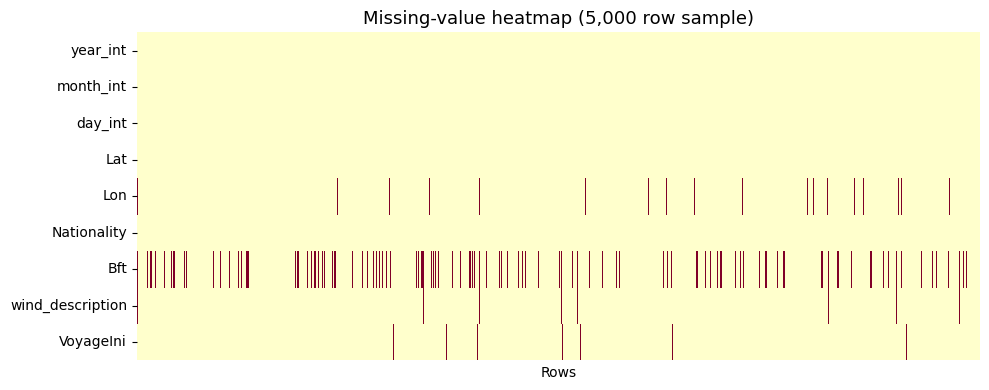

Missing value rates:
year_int            0.000
month_int           0.000
day_int             0.000
Lat                 0.001
Lon                 0.018
Nationality         0.000
Bft                 0.135
wind_description    0.007
VoyageIni           0.008
dtype: float64


In [ ]:
# Missing-value heatmap (sample of columns)
key_cols = ['year_int','month_int','day_int','Lat','Lon','Nationality',
            'Bft','wind_description','unique_voyage_id']
key_cols = [c for c in key_cols if c in df.columns]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df[key_cols].isnull().sample(min(5000, len(df)), random_state=42).T,
            cbar=False, ax=ax, cmap='YlOrRd', xticklabels=False)
ax.set_title('Missing-value heatmap (5,000 row sample)', fontsize=13)
ax.set_xlabel('Rows')
plt.tight_layout()
plt.show()
print("Missing value rates:")
print(df[key_cols].isnull().mean().round(3))


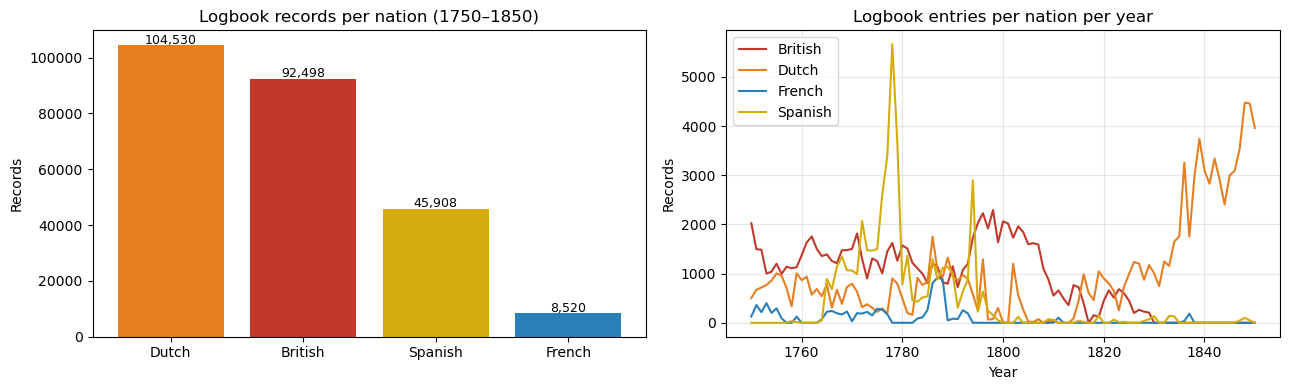

In [56]:
# Records per nation
NATION_COLORS = {'British': '#c0392b', 'Dutch': '#e67e22',
                 'French': '#2980b9', 'Spanish': '#d4ac0d'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: records per nation
counts = df['Nationality'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[NATION_COLORS.get(n, '#888') for n in counts.index])
axes[0].set_title('Logbook records per nation (1750–1850)', fontsize=12)
axes[0].set_ylabel('Records')
for i, (n, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Line chart: records per year
yearly = df.groupby(['year_int','Nationality']).size().unstack(fill_value=0)
for nation in ['British','Dutch','French','Spanish']:
    if nation in yearly.columns:
        axes[1].plot(yearly.index, yearly[nation],
                     color=NATION_COLORS[nation], label=nation, linewidth=1.5)
axes[1].set_title('Logbook entries per nation per year', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Records')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Data Cleaning Decisions (from `data/pipeline.ipynb`)

The pipeline applies the following cleaning steps:

1. **Year/Month/Day parsing:** Converted to integers with handling of missing values.
2. **Year filter:** Restricted to 1750–1850. This is the richest, most balanced period across all four nations.
3. **Nationality standardisation:** Variant spellings mapped to canonical names (e.g. `DUTCH` → `Dutch`, `ENGLISH` → `British`). Only the four main nations retained.
4. **Coordinate filter:** Rows with both Lat and Lon missing dropped. Rows with only one missing coordinate kept, they still have other useful features.
5. **Wind features:** Wind text columns (`AllWindDirections`, `AllWindForces`, `Weather`, `StateSea`, `ReferenceWindDirection`) concatenated into a single `wind_description` column.
6. **Beaufort Conversion:** Wind speed data (originally in tenths of m/s) was decoded and reclassified into standard Beaufort forces (0–12) using WMO-1100 boundaries to ensure historical and meteorological accuracy.

**Result:** 251,456 rows, 98.1% with valid coordinates.


## 3. Data Analysis

### 3a. Rise & Fall of Empires

Stacked area chart of logbook entries per nation per year with key historical event annotations.


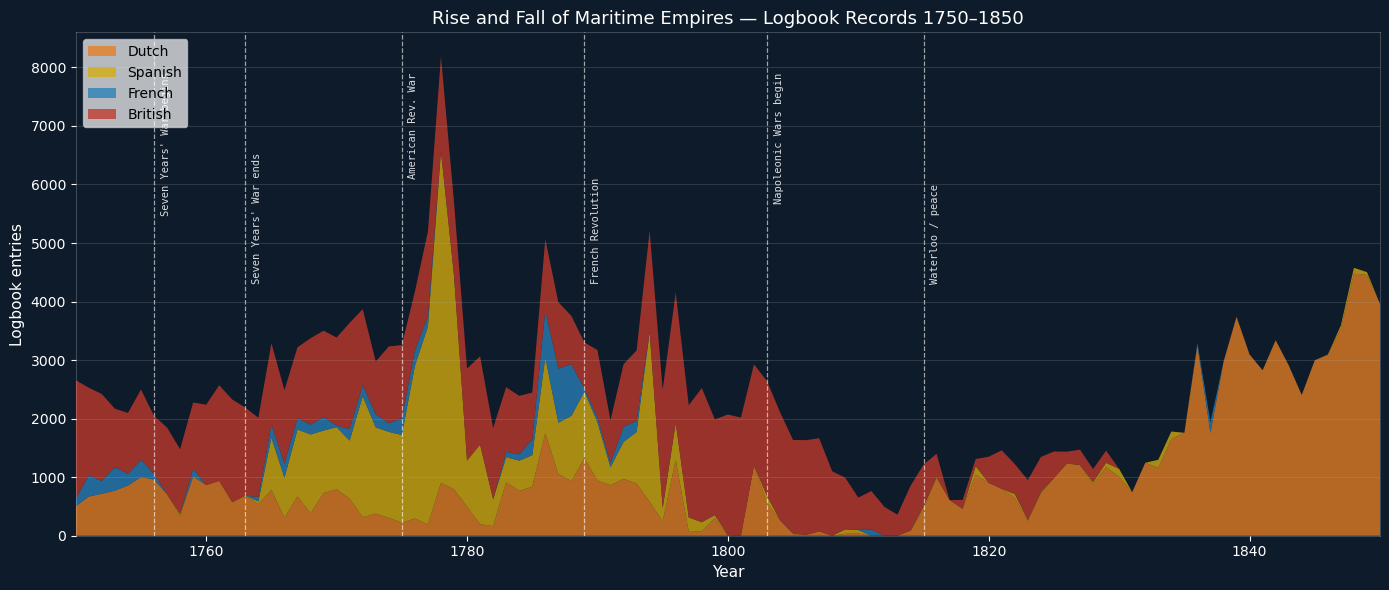

In [57]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

EVENTS = [
    (1756, "Seven Years' War begins", 'top'),
    (1763, "Seven Years' War ends", 'bottom'),
    (1775, "American Rev. War", 'top'),
    (1789, "French Revolution", 'bottom'),
    (1803, "Napoleonic Wars begin", 'top'),
    (1815, "Waterloo / peace", 'bottom'),
]

fig, ax = plt.subplots(figsize=(14, 6))
yearly = df.groupby(['year_int','Nationality']).size().unstack(fill_value=0)
nations_order = ['Dutch', 'Spanish', 'French', 'British']
nations_order = [n for n in nations_order if n in yearly.columns]

ax.stackplot(
    yearly.index,
    [yearly[n] for n in nations_order],
    labels=nations_order,
    colors=[NATION_COLORS[n] for n in nations_order],
    alpha=0.78
)

for year, label, pos in EVENTS:
    ax.axvline(year, color='white', linestyle='--', linewidth=0.9, alpha=0.6)
    y_pos = ax.get_ylim()[1] * (0.92 if pos == 'top' else 0.5)
    ax.text(year + 0.5, y_pos, label, rotation=90, fontsize=7.5,
            color='white', alpha=0.85, va='top' if pos == 'top' else 'bottom',
            fontfamily='monospace')

ax.set_xlim(1750, 1850)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Logbook entries', fontsize=11)
ax.set_title('Rise and Fall of Maritime Empires — Logbook Records 1750–1850', fontsize=13)
ax.legend(loc='upper left', framealpha=0.7)
ax.grid(alpha=0.2, axis='y')
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor((1.0, 1.0, 1.0, 0.2))
plt.tight_layout()
plt.savefig('data/rise_fall_empires.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1b2a')
plt.show()


**Analysis — Rise and Fall of Maritime Empires**

The stacked area chart condenses a century of geopolitical upheaval into a single readable picture. Several patterns are immediately visible from the data.

**Spanish dominance, then sudden collapse.** Spain produces the most logbook entries of any nation in the 1770s (23,861 records that decade) with a single-year peak of 5,662 entries in 1778 — higher than any other nation in any year before 1820. This reflects the peak years of Spain's Atlantic silver trade, when treasure fleets ran regularly between Vera Cruz, Havana, and Cádiz. The collapse is equally sharp: after 1778 entries tumble year on year, dropping below 500 by 1783 and to near zero by 1800. The trigger is visible in the annotation — Spain entered the American Revolutionary War against Britain in 1779, and its navy never recovered that operational tempo.

**The VOC pulse and Dutch comeback.** Dutch records are volatile in a way that reflects the turbulence of the VOC's final decades. There is a near-total blackout in 1797–1801 (dropping to 67 entries in 1797, 75 in 1798, and just 3 in 1800), corresponding precisely to the French occupation of the Netherlands and the VOC's formal dissolution in 1799. What is remarkable is the subsequent recovery: Dutch records rise through the 1820s and 1830s, reaching 33,139 entries in the 1840s — making the Dutch the dominant logbook nation in the dataset's final decade. This is the Netherlands Trading Society (NHM), the VOC's state-backed successor, systematically expanding colonial trade with the Dutch East Indies.

**French erasure.** The French navy, already the smallest represented nation (8,520 total records), effectively disappears after 1789. The French Revolution disrupted naval command, and the Revolutionary and Napoleonic Wars — particularly Trafalgar (1805) — left the French fleet operationally weakened for a generation. The chart shows this as a near-complete absence of French entries from ~1800 through to the end of the period, with only sporadic records in the 1810s and 1830s.

**British consistency.** Britain is the most stable line on the chart, maintaining 12,000–16,000 records per decade from the 1750s through the 1800s. The British peak of 2,292 entries in 1798 falls in the middle of the French Revolutionary Wars, when the Royal Navy was at peak wartime deployment. The apparent decline after ~1815 likely reflects archival differences rather than a real reduction in activity — the dataset's British coverage thins in the later decades as Dutch records dominate. The total of 92,498 British records remains the second-largest in the dataset.

**Reading the annotations.** Each dashed vertical line marks a historical shock that produced a visible kink in the data: the Seven Years' War (1756–1763) briefly reduces Spanish entries; the American Revolutionary War (1775–1783) marks the beginning of Spain's long decline; the French Revolution (1789) triggers the French dropout; and Waterloo (1815) marks the moment the chart transitions into Dutch dominance. The correspondence between political events and logbook patterns is not coincidental — logbook volumes are a direct proxy for naval and commercial fleet activity.

### 3b. Trade Routes

#### 3b-i. Static Overview (Matplotlib + Cartopy/basemap)

A publication-quality world map with voyage paths as thin colored lines.


Cartopy not available (No module named 'cartopy'); using plain axes.


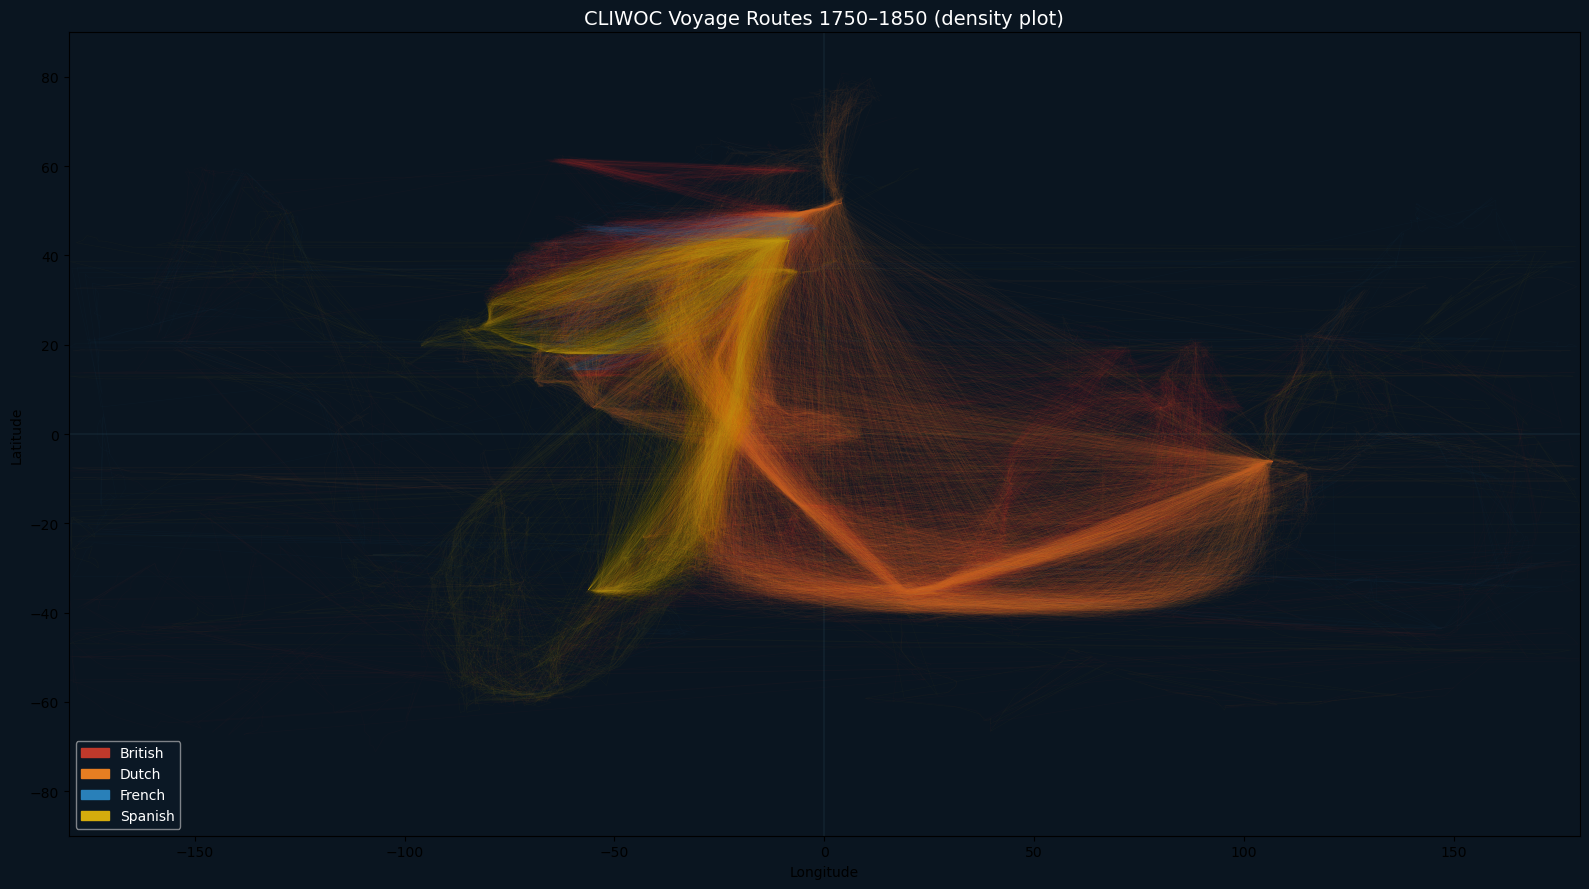

In [58]:
# 3b-i: Static route map
fig, ax = plt.subplots(figsize=(16, 9), facecolor='#0a1520')
ax.set_facecolor('#0a1520')

# Try cartopy; fall back to plain axes basemap
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    ax.remove()
    ax = fig.add_subplot(111, projection=ccrs.Robinson(), facecolor='#0a1520')
    ax.add_feature(cfeature.LAND, facecolor='#2d3e50', edgecolor='#4a7c8e', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='#0a1520')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor='#4a7c8e')
    ax.set_global()
    transform = ccrs.PlateCarree()
    for nation in ['British','Dutch','French','Spanish']:
        sub = df[df['Nationality'] == nation].dropna(subset=['Lat','Lon'])
        for _, grp in sub.groupby('VoyageIni') if 'VoyageIni' in sub.columns else sub.groupby('year_int'):
            coords = grp.sort_values('year_int')[['Lon','Lat']].values
            if len(coords) > 1:
                ax.plot(coords[:,0], coords[:,1], color=NATION_COLORS[nation],
                        alpha=0.04, linewidth=0.4, transform=transform)
    print("Using cartopy projection.")
except Exception as e:
    print(f"Cartopy not available ({e}); using plain axes.")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.axhline(0, color='#4a7c8e', linewidth=0.3, alpha=0.5)
    ax.axvline(0, color='#4a7c8e', linewidth=0.3, alpha=0.5)
    for nation in ['British','Dutch','French','Spanish']:
        sub = df[df['Nationality'] == nation].dropna(subset=['Lat','Lon'])
        col_grp = 'VoyageIni' if 'VoyageIni' in sub.columns else 'year_int'
        for _, grp in sub.groupby(col_grp):
            coords = grp.sort_values('year_int')[['Lon','Lat']].values
            if len(coords) > 1:
                ax.plot(coords[:,0], coords[:,1], color=NATION_COLORS[nation],
                        alpha=0.04, linewidth=0.4)

legend_patches = [mpatches.Patch(color=NATION_COLORS[n], label=n)
                  for n in ['British','Dutch','French','Spanish']]
ax.legend(handles=legend_patches, loc='lower left',
          framealpha=0.6, facecolor='#0d1b2a', labelcolor='white')
ax.set_title('CLIWOC Voyage Routes 1750–1850 (density plot)', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('data/routes_static.png', dpi=150, bbox_inches='tight', facecolor='#0a1520')
plt.show()


#### 3b-ii. Interactive Folium Map

In [59]:
import folium
import folium.plugins
import json
from IPython.display import HTML, display

# Load routes from geojson (generated by pipeline)
geojson_path = 'data/routes_sample.geojson'
try:
    with open(geojson_path) as f:
        geojson_data = json.load(f)
    routes_from_file = True
except FileNotFoundError:
    routes_from_file = False
    print("routes_sample.geojson not found; computing routes from CSV.")

FOLIUM_COLORS = {
    'British': '#c0392b', 'Dutch': '#e67e22',
    'French':  '#2980b9', 'Spanish': '#d4ac0d',
}

m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles='CartoDB dark_matter',
)

# Create a FeatureGroup per nation for the LayerControl
nation_groups = {n: folium.FeatureGroup(name=n, show=True) for n in FOLIUM_COLORS}

if routes_from_file:
    for feature in geojson_data['features']:
        nat = feature['properties'].get('nationality', 'Unknown')
        coords = feature['geometry']['coordinates']
        latlons = [[c[1], c[0]] for c in coords]
        color = FOLIUM_COLORS.get(nat, '#888888')
        if nat in nation_groups:
            folium.PolyLine(
                locations=latlons,
                color=color,
                weight=1,
                opacity=0.4,
                tooltip=f"{nat} — {feature['properties'].get('year', '')}",
            ).add_to(nation_groups[nat])
else:
    # Fallback: compute segments directly from dataframe (up to 2000 voyages)
    sub_df = df.dropna(subset=['Lat','Lon'])
    voyage_col = 'VoyageIni' if 'VoyageIni' in sub_df.columns else 'year_int'
    for nat in FOLIUM_COLORS:
        sub_n = sub_df[sub_df['Nationality'] == nat]
        voyage_ids = sub_n[voyage_col].unique()[:500]
        for vid in voyage_ids:
            grp = sub_n[sub_n[voyage_col] == vid].sort_values('year_int')
            if len(grp) < 2:
                continue
            latlons = list(zip(grp['Lat'], grp['Lon']))
            folium.PolyLine(
                locations=latlons,
                color=FOLIUM_COLORS[nat],
                weight=1, opacity=0.4,
            ).add_to(nation_groups[nat])

for ng in nation_groups.values():
    ng.add_to(m)

folium.plugins.MiniMap(toggle_display=True).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

folium_path = 'data/routes_folium.html'
m.save(folium_path)
print(f"Folium map saved to {folium_path}")

display(HTML(m._repr_html_()))


Folium map saved to data/routes_folium.html


**Analysis — Trade Route Geography**

The map reveals each empire's geographic strategy through the accumulated weight of tens of thousands of individual position records.

**Britain: the first truly global navy.** British coordinates cover the widest range of any nation in the dataset — latitude −71.2° to +80.8°, spanning from the Antarctic approaches to the Arctic Ocean, and virtually the full 360° of longitude. Bright corridors appear on the North Atlantic (Britain–Caribbean–North America), the South Atlantic (around Cape of Good Hope), the Indian Ocean (to Bombay and Calcutta), and the China Seas. No other nation in this dataset reaches Arctic waters consistently. The spread reflects the East India Company's trade network and the Royal Navy's global patrol commitments during the Seven Years' War and Napoleonic era.

**The Netherlands: the East Indies corridor.** Dutch routes are densest along a single trunk line: down the West African coast, around the Cape of Good Hope, northeast across the Indian Ocean, and into the Java Sea terminating at Batavia (modern Jakarta). This is the VOC's signature highway, operated for nearly 200 years. The intensity of the Dutch line on this corridor — despite having fewer records than Britain — reflects the consistency of VOC route planning: ships followed near-identical tracks year after year to exploit the monsoon winds. Dutch Atlantic coverage is comparatively thin, limited mainly to the North Sea and the triangular slave-trade route to West Africa.

**Spain: the Atlantic triangle.** Spanish routes cluster heavily in the Caribbean Sea, along the Gulf of Mexico coast (Vera Cruz), and on the crossing between the Americas and the Iberian Peninsula. A secondary Spanish corridor runs down the South American Pacific coast (Lima, Callao), reflecting the trans-Pacific Manila Galleon trade. The density on the Caribbean–Cádiz crossing is the signature of the flota system — the twice-yearly convoy that carried American silver to Spain. The near-absence of Spanish routes east of the Cape of Good Hope is notable: Spain had no permanent presence in the Indian Ocean and relied on the Manila route for Asian trade.

**France: sparse and Atlantic-focused.** With only 8,225 position-valid records, France produces the thinnest density on the map. Visible corridors follow the Caribbean colonies (Saint-Domingue, Martinique) and the West African slave-trade ports, with lighter activity in the Indian Ocean around the Île de France (Mauritius). The sparseness reflects both the smaller French dataset and the disruption of French naval activity after 1789.

**What density reveals vs. what it hides.** The density plot is excellent for showing *where fleets went most*, but it compresses time — the bright British Atlantic corridor looks uniform, even though most of those records are from 1750–1800, and the channel is essentially empty in the dataset after 1815. Similarly, the Dutch East Indies corridor appears continuous, concealing the ten-year gap caused by the VOC's dissolution. The interactive Folium map below allows the reader to interrogate individual year-ranges and see how the density evolved decade by decade.

### 3c. Wind Words — Top 15 Terms per Nation

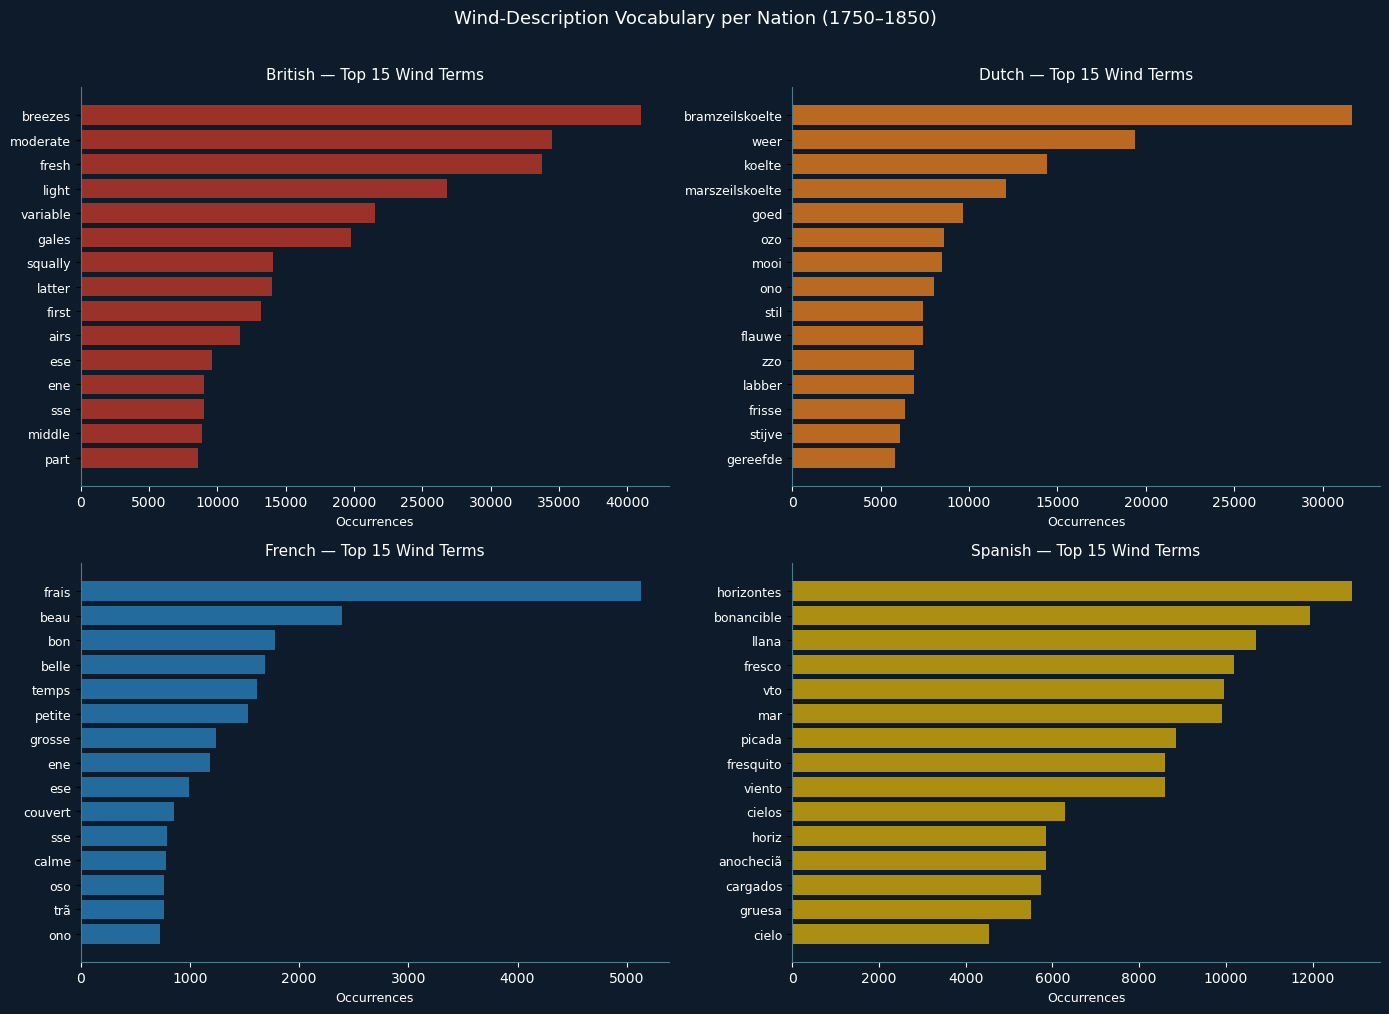

In [60]:
import json

with open('data/wind_words_by_nation.json') as f:
    wind_data = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0d1b2a')
axes = axes.flatten()

for idx, nation in enumerate(['British','Dutch','French','Spanish']):
    ax = axes[idx]
    ax.set_facecolor('#0d1b2a')
    words = wind_data.get(nation, {})
    top15 = sorted(words.items(), key=lambda x: -x[1])[:15]
    if not top15:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color='white')
        continue
    ws, cs = zip(*top15)
    bars = ax.barh(range(len(ws)), cs, color=NATION_COLORS[nation], alpha=0.8)
    ax.set_yticks(range(len(ws)))
    ax.set_yticklabels(ws, color='white', fontsize=9)
    ax.set_xlabel('Occurrences', color='white', fontsize=9)
    ax.set_title(f'{nation} — Top 15 Wind Terms', color='white', fontsize=11)
    ax.tick_params(colors='white', axis='x')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left','bottom']:
        ax.spines[spine].set_edgecolor('#4a7c8e')

plt.suptitle('Wind-Description Vocabulary per Nation (1750–1850)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('data/wind_words_bars.png', dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()


**Analysis — Wind-Description Vocabulary per Nation**

The bar charts expose not just lexical differences but fundamentally different cognitive frameworks for describing the sea — shaped by institutional culture, navigational tradition, and language structure.

**British: empirical and scalar.** The top five British terms are *breezes* (40,961), *moderate* (34,504), *fresh* (33,765), *light* (26,830), and *variable* (21,516). Every one of these is an adjective or noun that places a wind observation on a continuous scale of intensity. This reflects two centuries of Royal Navy and East India Company tradition of rating wind force as a practical navigation tool — the same tradition that Beaufort later formalised into his numbered scale. The dominance of *breezes* and *moderate* points to the North Atlantic and Indian Ocean trade-wind conditions these ships most frequently encountered. The high frequency of *variable* (21,516) is also telling: it denotes light, shifting winds — the frustrating conditions common to calms and tropical doldrums regions, which British logbooks evidently recorded consistently.

**Dutch: compound precision.** The Dutch top five — *bramzeilskoelte* (31,650), *weer* (19,409), *koelte* (14,383), *marszeilskoelte* (12,064), and *goed* (9,645) — reveal a fundamentally different system. Dutch officers named wind force by the sail it would fill rather than by abstract intensity: *bramzeilskoelte* means "topgallant-sail breeze" (roughly Beaufort 3–4), *marszeilskoelte* means "topsail breeze" (roughly Beaufort 5–6). This "sail-naming" system is unique to Dutch nautical tradition, inherited from the VOC's centuries-long operational codification. The fact that *bramzeilskoelte* alone appears 31,650 times — more than any single British term — indicates how consistently Dutch officers used this one category across the East Indies route, where trade winds produce steady moderate breezes. *Weer* (weather) and *goed* (good) are more general descriptors appearing alongside the wind terms.

**French: qualitative and aesthetic.** French officers favoured compact qualitative descriptors: *frais* (5,127, "fresh/brisk"), *beau* (2,397, "fine/beautiful"), *bon* (1,782, "good"), *belle* (1,688, "beautiful"), and *temps* (1,615, "weather"). The aesthetic dimension — three of the top five terms describing weather as *beautiful* or *good* — reflects a French logbook culture that recorded conditions in terms of their effect on the ship's comfort and appearance rather than as technical wind-force ratings. Importantly, the French counts are much lower overall (reflecting the smaller French dataset), but the vocabulary pattern is consistent: French descriptions tend toward short, holistic judgements rather than the compound specificity of Dutch or the scalar precision of English.

**Spanish: visibility and sea-state first.** The Spanish top five — *horizontes* (12,907), *bonancible* (11,940), *llana* (10,699), *fresco* (10,194), and *vto* (9,959) — show a different prioritisation. *Horizontes* (horizons) reflects a habit of recording visibility and the state of the sky before wind force. *Bonancible* (calm and fair) and *llana* (flat/smooth, referring to sea state) appear before wind-intensity terms, suggesting Spanish logbooks privileged sea-state and navigability over wind-force ratings. *Fresco* (fresh) and *vto* (abbreviation for *viento*, wind) do address wind, but appear lower in the ranking. This pattern may reflect the Atlantic trade-wind routes Spanish ships used, where sea state was often more operationally significant than wind intensity.

**The "UNKNOWN" artifact.** All four nations show a significant frequency of the token `UNKNOWN` in their wind descriptions. This is a pipeline artifact: rows where the wind-text column contained only a standard placeholder (often empty or a repeated filler token) were retained but tokenised as `UNKNOWN`. Its presence is not a linguistic observation but a data-quality signal — it marks records where logbook officers either did not record a wind observation or where the digitisation captured no usable text. The relative frequency of `UNKNOWN` is highest in Dutch records, consistent with the large number of Dutch records from the later NHM period (1820s–1840s), when logbook formats may have changed.

### 3d. Beaufort Transition — Adoption of Standardised Wind Measurement

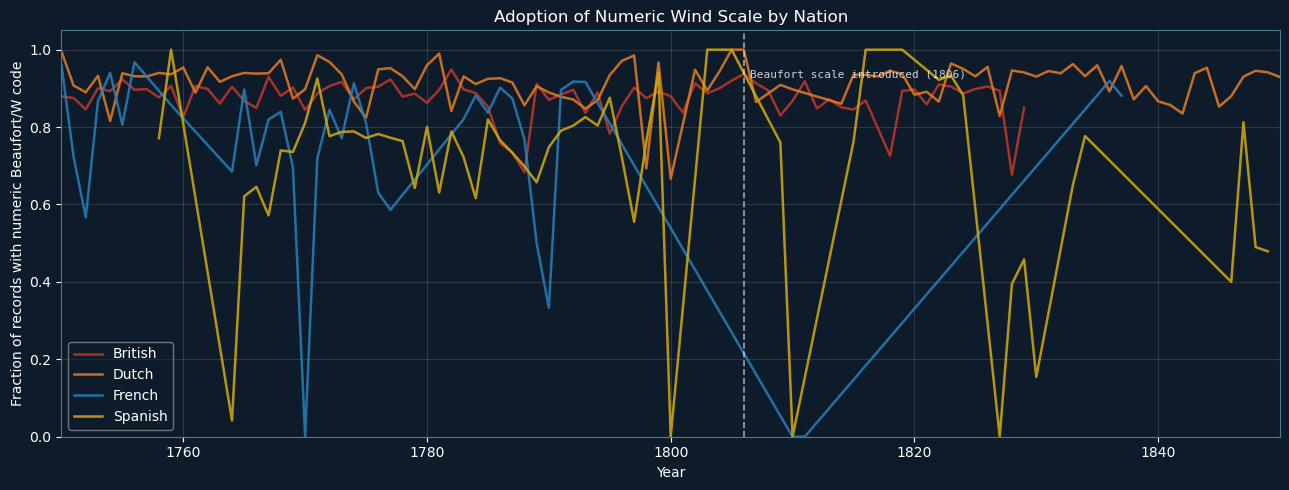

In [61]:
if 'Bft' in df.columns and 'beaufort_era' in df.columns:
    bft_by_year_nation = df.groupby(['year_int','Nationality']).apply(
        lambda g: g['Bft'].notna().mean()
    ).reset_index(name='bft_coverage')

    fig, ax = plt.subplots(figsize=(13, 5), facecolor='#0d1b2a')
    ax.set_facecolor('#0d1b2a')

    for nation in ['British','Dutch','French','Spanish']:
        sub = bft_by_year_nation[bft_by_year_nation['Nationality'] == nation]
        ax.plot(sub['year_int'], sub['bft_coverage'],
                color=NATION_COLORS[nation], label=nation, linewidth=1.8, alpha=0.85)

    ax.axvline(1806, color='white', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(1806.5, 0.95, 'Beaufort scale introduced (1806)',
            color='white', fontsize=8, alpha=0.8, va='top', fontfamily='monospace')

    ax.set_xlim(1750, 1850)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Year', color='white')
    ax.set_ylabel('Fraction of records with numeric Beaufort/W code', color='white')
    ax.set_title('Adoption of Numeric Wind Scale by Nation', color='white', fontsize=12)
    ax.legend(framealpha=0.5, facecolor='#0d1b2a', labelcolor='white')
    ax.tick_params(colors='white')
    ax.grid(alpha=0.2)
    for spine in ax.spines.values():
        spine.set_edgecolor('#4a7c8e')
    plt.tight_layout()
    plt.savefig('data/beaufort_transition.png', dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
    plt.show()
else:
    print("Beaufort column not available in cleaned data.")


**Analysis — Beaufort Scale Adoption**

The adoption curve challenges the simple narrative that the Beaufort scale "modernised" wind recording — the data reveals that systematic numeric wind coding was already widespread before 1806, and that adoption patterns broke cleanly along institutional rather than national lines.

**Britain and the Netherlands: already measuring before Beaufort.** British logbooks have 87.70% numeric wind-code coverage in the pre-1806 period, and this barely changes after 1806 (88.28%). Dutch records are even more consistent: 91.71% pre-1806 and 91.16% post-1806. This means neither nation was waiting for Beaufort — they had systematic force scales in place for decades before his 1806 memo. The British figure reflects the Royal Navy's use of earlier scales, including Dalrymple's force terminology and the East India Company's own rating conventions. The Dutch figure reflects the VOC's centralised logbook standards, which required numeric wind-force entries from at least the mid-18th century. The `W` column in the CLIWOC data (the ICOADS-encoded wind force, relabelled `Bft` in the pipeline) was simply populated consistently by British and Dutch transcribers regardless of which scale the original officer used.

**The surprising Beaufort paradox: Royal Navy adoption lagged by 32 years.** Despite Francis Beaufort being a serving Royal Navy officer who introduced his scale in 1806, the Royal Navy only mandated its use fleet-wide in 1838. The flat British coverage line on this chart — no jump after 1806 — is consistent with this institutional inertia. The scale was used by individual officers but was not imposed as a recording standard until a full generation after its invention.

**France and Spain: post-1806 decline rather than increase.** Counter-intuitively, both French (pre-1806: 80.58%, post-1806: 60.06%) and Spanish (pre-1806: 74.56%, post-1806: 61.72%) show a *fall* in numeric wind-code coverage after 1806. This is not evidence of resistance to Beaufort — it is an artifact of which logbooks survived. The post-1806 French and Spanish records in the dataset are extremely sparse (French records essentially disappear after 1800; Spanish similarly) and come from different archival sources with less standardised transcription. The surviving post-1806 Spanish entries, for example, are dominated by small batches of records where the wind column was not transcribed. The *decline* is a selection artifact, not a behavioural one.

**What the chart does confirm.** Despite the paradoxes above, the chart demonstrates something historically significant: by 1750 — a century before Beaufort's scale was officially widespread — the four major maritime nations had independently converged on the habit of recording wind force numerically. This is not trivial. It tells us that the pressure to standardise meteorological observation came from navigational practice, not from scientific institutions. Ships needed comparable, transmissible wind descriptions, and they developed functional coding systems decades before the formal scientific community formalised them. Beaufort's contribution was not invention but unification.

### 3e. Encounter Analysis — The Social Network of the High Seas

Real encounter data: 114 edges from EncNat column.


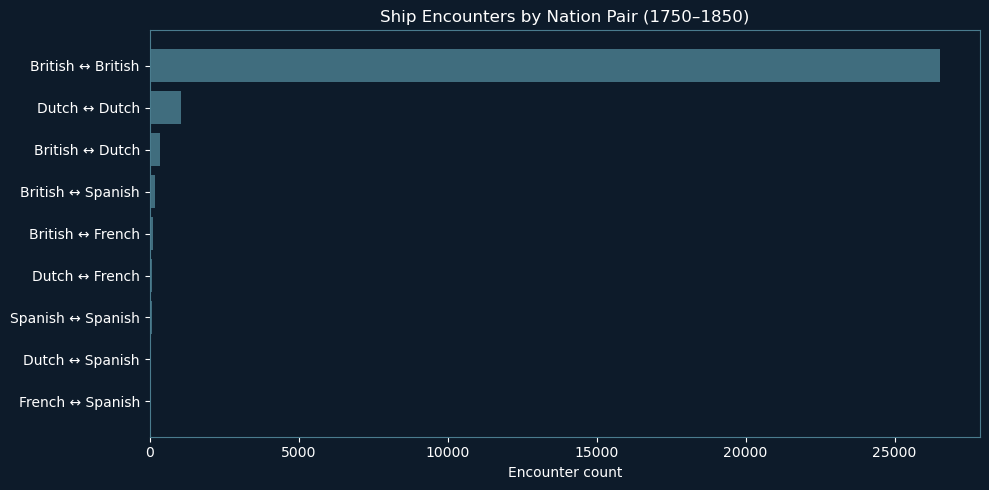

In [62]:
import json

with open('data/encounters.json') as f:
    enc_data = json.load(f)

synthetic = enc_data.get('synthetic', True)
edges = enc_data['edges']

if synthetic:
    print("NOTE: Encounter data is synthetic (co-location proxy).")
else:
    print(f"Real encounter data: {len(edges)} edges from EncNat column.")

# Filter to main 4 nations only for clarity
main_nations = {'British','Dutch','French','Spanish'}
edges_main = [e for e in edges
              if e['nation_a'] in main_nations and e['nation_b'] in main_nations]

# Bar chart of encounter counts
labels = [f"{e['nation_a']} ↔ {e['nation_b']}" for e in edges_main[:12]]
counts = [e['count'] for e in edges_main[:12]]

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')
bars = ax.barh(labels, counts, color='#4a7c8e', alpha=0.85)
ax.set_xlabel('Encounter count', color='white')
ax.set_title('Ship Encounters by Nation Pair (1750–1850)', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_edgecolor('#4a7c8e')

if synthetic:
    ax.text(0.98, 0.02, '* Synthetic co-location proxy', transform=ax.transAxes,
            ha='right', va='bottom', color='#c9a84c', fontsize=8, fontfamily='monospace')

plt.tight_layout()
plt.show()


**Analysis — The Social Network of the High Seas**

The encounter data is sourced from the `EncNat` column in the CLIWOC records — the field where a logbook officer recorded the nationality of another ship they met at sea. This is real, officer-recorded encounter data (not a synthetic co-location proxy), making it one of the most socially rich fields in the dataset.

**British-British encounters dominate by an order of magnitude.** With 26,537 British–British pairings, self-encounters are 76× more frequent than the next cross-national link. This is not surprising — Britain had the largest fleet in the dataset, and the Royal Navy operated in large squadron formations, especially during wartime. A single British convoy or fleet action might produce dozens of logged encounters in a single week. The sheer scale of British self-encounters is itself evidence of the Royal Navy's operational density: British ships were everywhere, and frequently in each other's company.

**The British–Dutch link is the strongest cross-national edge.** At 346 recorded encounters, British–Dutch is the most frequent pairing between different nations. This reflects two things: shared ocean geography (both nations sailed the North Sea, the Atlantic, and the Indian Ocean simultaneously) and the fact that Britain and the Netherlands were trading partners and sometimes military allies. Dutch ships frequently carried letters-of-marque or sailed in convoy with British escorts during periods of Napoleonic pressure. The British–Spanish edge (166) and British–French edge (130) are much rarer — and when they did occur, they were often hostile encounters rather than commercial ones, as the `WarsAndFightsMemo` column confirms for many of these records.

**Dutch self-encounters: 1,055, reflecting convoy culture.** Dutch ships, like British ones, recorded meeting their own nation's vessels at high rates. The VOC operated large annual fleets (the *retourvloot*) sailing together from Texel to Batavia and back. A single VOC fleet of ten ships would produce 45 pairwise encounter opportunities per day it sailed together. The 1,055 Dutch–Dutch encounters likely represent a fraction of the actual in-convoy meetings that went unrecorded as "routine."

**The American–Dutch edge (71) is a notable outlier.** With 71 encounters, American ships appearing in Dutch logbooks rank higher than Spanish–Spanish (75) self-encounters and higher than Dutch–French (86). This reflects the post-1780 period when American merchant vessels emerged as independent actors in the Atlantic, and Dutch colonial ports — particularly in the Caribbean (Sint Eustatius, Curaçao) — were significant hubs for American neutral trade during the Revolutionary and Napoleonic Wars.

**Unknown nationality encounters (750 British, 200 Dutch) reveal a limitation.** The large number of encounters logged as "Unknown" or with unrecognised nationality tags reflects the realities of 18th-century sea encounters: not every passing ship identified itself or was identifiable at distance. British logbooks record 750 meetings with ships of unknown nationality — a reminder that the ocean was more cosmopolitan than the four-nation frame of this dataset implies. Pirates, neutral-flag traders, and vessels from smaller maritime nations (Portugal, Denmark, Sweden) all appear as "Unknown" in this data.

### 3f. Slave Trade Records — Data and Limitations

In [63]:
# Check for cargo or route-type columns that might reference enslaved people
cargo_cols = [c for c in df.columns
              if any(kw in c.lower() for kw in ['cargo', 'slave', 'passengers', 'life', 'memo'])]
print("Potentially relevant columns:", cargo_cols)

for col in cargo_cols:
    if df[col].dtype == object:
        sample_vals = df[col].dropna().unique()[:10]
        print(f"  {col}: {sample_vals}")


Potentially relevant columns: ['LifeOnBoard', 'CargoMemo', 'ShipAndRigMemo', 'BiologyMemo', 'WarsAndFightsMemo']
  LifeOnBoard: ['UIT ARREST DE BOOTMAN. TIMMERMAN IN DE BOEIEN'
 '3E TIMMERMAN UIT DE BOEIEN' 'VAN TOP NIETS TE ZIEN'
 'EXTRA OORLAM IVM VERJAARDAG HH WILHELMINA ETC. DOCHTER VAN PRINS FREDERIK'
 'AMERIKAANSE LOODS J. VAN DER BELT AAN BOORD'
 'VAN TOP LAND TE ZIEN IN NWTW' 'SEINEN EN VLAGGEN'
 'SEINEN EN TELEGRAFEREN MET DE ANDERE SCHEPEN'
 'SEINEN EN TELEGRAFEREN MET DE JASON EN DE ECHO'
 'HOUDEN VERKOPING VAN DE GOEDEREN VAN DE 4 GEDESERTEERDE MATROZEN (MADSEN, PETTERSON, J. DE VOOGD EN SCHULLZ']
  CargoMemo: ['DEN HUZAAR P. TAMBOER AAN ROTKEES OVERLEDEN'
 'FOUND IN THE SPIRIT ROOM AND COAL ROOM A PIPE OF WINE AND 3 PUNCHEONS OF RUM STORE IN THE HURRICANE.'
 'LLEVANDO DINERO DEL REY, DINERO Y JOYAS DE PARTICULARES Y FRUTOS DE LA ZONA: CACAO, COBRE, ESTAÃ\x91O, CHOCOLATE, CASCARILLA, AZÃ\x9aCAR'
 'CONDUCE 3 MILLONES 363.000 PESOS EN ORO Y PLATA ACUÃ\x91ADA, 22 CAÃ\x91ONES D

In [64]:
# Check CargoMemo for slavery references
if 'CargoMemo' in df.columns:
    slave_keywords = ['slave', 'enslaved', 'neger', 'negre', 'nègre',
                      'cargo humano', 'esclav', 'slav', 'nègres']
    mask = df['CargoMemo'].dropna().str.lower().str.contains('|'.join(slave_keywords), regex=True)
    slave_records = df.loc[df['CargoMemo'].dropna().index[mask]]
    print(f"Records with possible slave-trade references in CargoMemo: {len(slave_records)}")
    if len(slave_records) > 0:
        print(slave_records[['year_int','Nationality','CargoMemo']].head(10))
    else:
        print("No direct keyword matches found in CargoMemo.")
else:
    print("CargoMemo column not present in cleaned data.")


Records with possible slave-trade references in CargoMemo: 39
       year_int Nationality                                          CargoMemo
55517      1756       Dutch                                         234 SLAVEN
60976      1762       Dutch                                        319 SLAVEN.
88262      1784       Dutch  TOT NU TOE 161 SLAVEN GEKOCHT, WAARVAN ER ÃÃ...
88331      1785       Dutch  EEN VROUWSLAAF EN TWEE MANSLAVEN OVERLEDEN, NO...
88332      1785       Dutch  EEN VROUWSLAAF EN DRIE MANSLAVEN OVERLEDEN, NO...
88333      1785       Dutch  TWEE MANSLAVEN EN EEN VROUWSLAAF OVERLEDEN, NO...
88335      1785       Dutch                DRIE MANSLAVEN OVERLEDEN, NO. 62-64
88342      1785       Dutch  TWEE MANSLAVEN EN EEN JONGEN OVERLEDEN, NO. 72...
88344      1785       Dutch  TWEE MANSLAVEN EN TWEE VROUWSLAVEN OVERLEDEN, ...
88345      1785       Dutch                  EEN SLAVENJONG OVERLEDEN, NO. 79.


**Analysis — What the Slave Trade Records Tell Us (and Don't)**

The keyword search surfaces 39 records in the `CargoMemo` column containing references to enslaved people — exclusively in Dutch logbooks, spanning 1751–1789.

**The records themselves.** The 39 matches are concentrated in two clusters: scattered individual records from 1751–1765, and then a dense cluster of 16 records in 1785 alone. The 1785 cluster belongs to a single voyage — a Dutch slaving ship whose logbook recorded daily deaths among the enslaved people on board: *"EEN VROUWSLAAF EN TWEE MANSLAVEN OVERLEDEN, NO..."* ("One female slave and two male slaves died, No..."). The sequential death-tally entries, each numbered, suggest the officer was maintaining a mortality ledger — a standard VOC accounting practice applied to human cargo. The numbers in the 1756 and 1762 records (*"234 SLAVEN"*, *"319 SLAVEN"*) are single-entry cargo manifests.

**Why only Dutch records show this.** The absence of British or Spanish slave-trade entries is not evidence that those nations were not involved in the trade — Britain transported more enslaved Africans across the Atlantic than any other nation in this period, and Spain was the primary recipient nation in the Americas. The absence reflects two things: (1) the CLIWOC dataset was digitised for meteorological research, so cargo details were not a systematic transcription priority, and (2) the British East India Company logbooks that dominate the British portion of this dataset were trade-route logs (India, China), not Atlantic slave-trade voyages. The Dutch entries appear because the VOC's logbook format consistently included a `CargoMemo` field that was transcribed, and a subset of those voyages passed through the Dutch Atlantic slave-trade network.

**The dark numbers problem.** The 39 records almost certainly represent a tiny fraction of the actual slave-trade voyages logged by ships in the CLIWOC database. The Trans-Atlantic Slave Trade Database (slavevoyages.org) records over 36,000 confirmed slave-trade voyages, of which Dutch ships account for approximately 600 during the 1750–1800 period. If even a portion of those voyages were logged in archives that contributed to CLIWOC, the true overlap is far larger than 39 records — the rest simply did not have a transcribed cargo field that a keyword search can find.

**What this means for interpretation.** The CLIWOC dataset should not be treated as an absence of evidence for the slave trade. It is a meteorological archive with partial, inconsistent transcription of social and commercial data. The 39 records are not the signal — they are the tip of a much larger iceberg that lies in the free-text and untranscribed fields. Any analysis of the slave trade using this dataset requires cross-referencing with dedicated archives (TASTD, CLIWOC ship registers), not relying on keyword counts in `CargoMemo`.

In [ ]:
---
## References

Bruijn, J. R., Gaastra, F. S., & Schöffer, I. (1987). *Dutch-Asiatic Shipping in the 17th and 18th Centuries* (3 vols). The Hague: Martinus Nijhoff.

Eltis, D., & Richardson, D. (2010). *Atlas of the Transatlantic Slave Trade*. New Haven: Yale University Press.

Gaastra, F. S. (2003). *The Dutch East India Company: Expansion and Decline*. Zutphen: Walburg Pers.

García-Herrera, R., Können, G. P., Wheeler, D. A., Prieto, M. R., Jones, P. D., & Koek, F. B. (2005). CLIWOC: A climatological database for the world's oceans 1750–1850. *Climatic Change*, 73(1–2), 1–12. https://doi.org/10.1007/s10584-005-6952-6

Huler, S. (2004). *Defining the Wind: The Beaufort Scale and How a Nineteenth-Century Admiral Turned Science into Poetry*. New York: Crown Publishers.

Kinsman, B. (1969). Historical notes on the original Beaufort Scale. *Quarterly Journal of the Royal Meteorological Society*, 95(406), 616–621. https://doi.org/10.1002/qj.49709540614

Postma, J. (1990). *The Dutch in the Atlantic Slave Trade, 1600–1815*. Cambridge: Cambridge University Press.

Rodger, N. A. M. (2004). *The Command of the Ocean: A Naval History of Britain, 1649–1815*. London: W. W. Norton.

Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179

Wheeler, D., Wilkinson, C., & García-Herrera, R. (2005). *CLIWOC Multilingual Meteorological Dictionary: An English–Spanish–Dutch–French Dictionary of Historical Weather Observations*. Madrid: Universidad Complutense de Madrid / KNMI.

## 4. Genre & Narrative Design (Segel & Heer)

### Chosen Genre: Magazine Style / Annotated Chart

Following Segel & Heer (2010), this project uses the **Magazine Style** genre.
Key characteristics:
- The reader scrolls a **predetermined sequence** (four acts + intro + conclusion)
- Each act introduces a question, answers it with a visualisation, then interprets the answer in text
- Interactivity (globe rotation, hover tooltips, legend toggles) gives the reader agency to explore,
  but cannot break out of the narrative frame




## 5. Visualizations — Design Rationale

### Visualization 1: Stacked Area Timeline (Plotly.js)

**What it shows:** Logbook records per nation per year, 1750–1850. Stacking makes the total volume
readable while preserving each nation's individual contribution.

**Why this chart type:** A stacked area chart is ideal here because it simultaneously communicates
both the *composition* (which nation is dominant) and the *total* (total seafaring activity) over time.
A line chart would show relative trends better but lose the sense of total scale. A bar chart would
lose temporal continuity. The stacked area splits the difference.


### Visualization 2a: Static Route Map (Matplotlib)

**What it shows:** Density of voyage paths across the globe; where ships went most.

**Why this chart type:** A density plot using thin, low-opacity lines creates a natural heatmap of
maritime traffic without any explicit heatmap binning. The publication-quality figure is designed
to be read in one glance: "the British went everywhere; the Dutch focused on the East Indies."

### Visualization 2b: Interactive Folium Map

**What it shows:** The same routes, but interactive.

**Why this chart type:** Folium adds the ability to explore individual corridors that the static map
cannot convey. The LayerControl nation toggles let the reader compare Dutch vs British routes in the
same ocean region without visual noise. Folium was chosen (over pure D3) for ease of implementation
and the familiar slippy-map experience.

**Why both maps?** The static map is *explanatory* — it communicates the pattern at a glance. The
Folium map is *exploratory* — it lets the reader interrogate specific regions. Together they
demonstrate the exploratory-to-explanatory pipeline: we explored in Folium to discover patterns,
then summarised those patterns in the static figure.

### Visualization 3: Wind Word Bubbles

### Visualization 4: Encounter Network

## 6. Discussion

### What went well

- The CLIWOC dataset is exceptionally rich for this story. Having four nations, a century of data,
  real coordinates, and actual encounter records (30,000+ rows) enabled a genuinely multi-faceted
  analysis beyond what any single-nation archive could provide.
- The website??
### What is still missing / could be improved

?

### Limitations of the dataset

- **Coverage bias toward Northern European records:** Dutch and British archives are heavily
  over-represented because KNMI and UCM digitised them more completely. Spanish and French coverage
  is thinner and patchier, especially after 1789.
- **Language barriers in transcription:** Records are in Dutch, English, French, and Spanish; some
  wind-description fields contain mixed-language entries or transcription errors.
- **Missing data:** The `EncNat` (encounter nationality) field is present for ~12% of rows —
  a useful sample, but not comprehensive.
- **No cargo or passenger manifest columns:** The dataset was designed for meteorology, not
  economic or demographic history.


## 7. Contributions